# 04 — Modelagem (M1, M2, M3)

- **M1** expectativa de vida (regressão), **M2** mortalidade <5 (regressão),
  **M3** marco alto: proxy UHC ≥ 0.8 **e** LE ≥ 70 (classificação).
- Split **temporal** (sem vazamento): treino ≤ 2015, validação 2016–2019 (early stopping),
  teste 2020–2023. Baseline linear (imputação + padronização + Ridge/Logística) vs **XGBoost**.
- M3 não usa `uhc_index` como feature (o label é definido por ele).

In [1]:
import sys, json, warnings
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from config import settings
from src.utils.io import load_parquet
from src.analysis import eda
from src.viz import style

style.use_matplotlib()
pd.set_option("display.max_columns", 40, "display.width", 160, "display.precision", 2)
abt = load_parquet("gold", "abt_country_year")
print(f"ABT: {abt.shape[0]:,} linhas x {abt.shape[1]} colunas | "
      f"{abt.country_id.nunique()} paises | {abt.year.min()}-{abt.year.max()}")

ABT: 7,378 linhas x 37 colunas | 217 paises | 1990-2023


In [2]:
import joblib
from src.modeling.dataset import build_dataset, TARGETS
reps = json.loads((settings.MODELS_DIR / "all_eval.json").read_text())
rows = []
for r in reps:
    for m in ("linear", "xgb"):
        rows.append({"modelo": r["name"], "algoritmo": m, **{f"test_{k}": v for k, v in r[m]["test"].items()}})
pd.DataFrame(rows)

,modelo,algoritmo,test_rmse,test_mae,test_r2,test_accuracy,test_f1,test_precision,test_recall,test_brier,test_log_loss,test_ece,test_n,test_auc,test_pos_rate_test
0,life_expectancy_reg,linear,3.86,2.89,0.74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,life_expectancy_reg,xgb,2.95,2.12,0.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,child_mortality_reg,linear,20.73,14.26,0.54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,child_mortality_reg,xgb,14.76,7.74,0.77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,milestone_high_clf,linear,NaN,NaN,NaN,0.95,0.87,0.90,0.85,0.04,0.14,0.03,768.0,0.99,0.2
5,milestone_high_clf,xgb,NaN,NaN,NaN,0.96,0.89,0.93,0.86,0.03,0.11,0.02,768.0,0.99,0.2


**Leitura:** XGBoost supera o baseline linear nos três modelos (M1 R² ≈ 0.85 vs 0.74; M2 ≈ 0.77
vs 0.54). O M3 tem AUC alto também no baseline: o marco é quase uma função determinística dos
insumos (é um problema "fácil" por construção).

## Resíduos no teste: o choque da COVID

In [3]:
md_ = build_dataset("life_expectancy")
m1 = joblib.load(settings.MODELS_DIR / "life_expectancy_reg_xgb.joblib")
te = abt.loc[md_.X_test.index, ["country_id", "year"]].assign(y=md_.y_test, pred=m1.predict(md_.X_test))
te["resid"] = te.y - te.pred
by_year = te.groupby("year").resid.agg(["mean", "median", lambda s: np.sqrt((s**2).mean())]).rename(columns={"<lambda_0>": "rmse"})
by_year.round(2)

,mean,median,rmse
year,,,
2020,0.32,0.26,2.30
2021,-0.42,-0.34,2.92
2022,0.78,0.78,3.37
2023,1.45,1.35,3.10


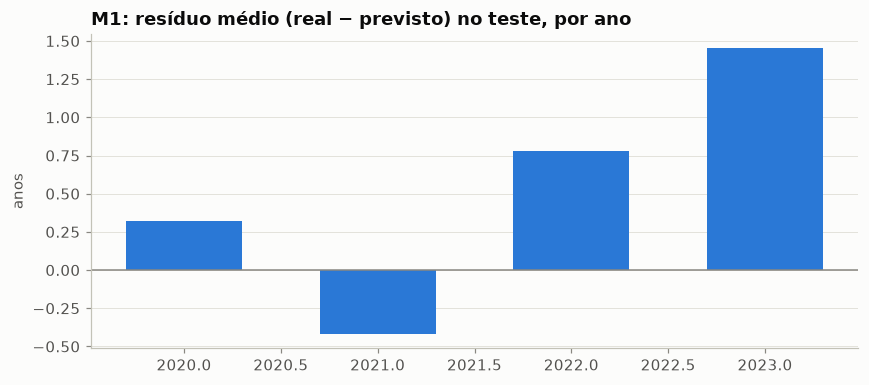

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(by_year.index, by_year["mean"], color=style.HIGHLIGHT, width=0.6)
ax.axhline(0, color=style.INK["muted"], lw=1)
ax.set_title("M1: resíduo médio (real − previsto) no teste, por ano"); ax.set_ylabel("anos")
plt.tight_layout(); plt.show()

**Leitura:** só **2021** (pico da pandemia) é superestimado (resíduo negativo) — o modelo não
"sabe" da COVID. Em 2022–2023 acontece o contrário: ele **subestima** cada vez mais (+0.8 e
+1.5 ano), porque a recuperação pós-pandemia e a tendência secular de ganho de LE não estão nas
features (o ano não é feature). O erro cresce com o horizonte de previsão — é o drift que o
monitoramento (F11) precisa capturar, e um argumento para retreinar periodicamente.

## Interpretação: SHAP

In [5]:
for r in reps:
    top = r["importance"]["top"]
    print(f"{r['name']:22} ({r['importance']['method']}): " + ", ".join(f"{k}={v:.2f}" for k, v in list(top.items())[:6]))

life_expectancy_reg    (shap): fertility=3.39, gdp_per_capita=2.19, sanitation_basic=0.95, urban_pct=0.56, water_safely=0.55, uhc_index=0.41
child_mortality_reg    (shap): fertility=13.96, gdp_per_capita=8.77, uhc_index=3.20, urban_pct=3.08, dpt_imm_pct=2.59, sanitation_basic=2.50
milestone_high_clf     (shap): gdp_per_capita=1.57, health_exp_per_capita=1.33, doctors_per_1000=1.09, nurses_per_1000=1.03, beds_per_1000=0.78, dpt_imm_pct=0.52


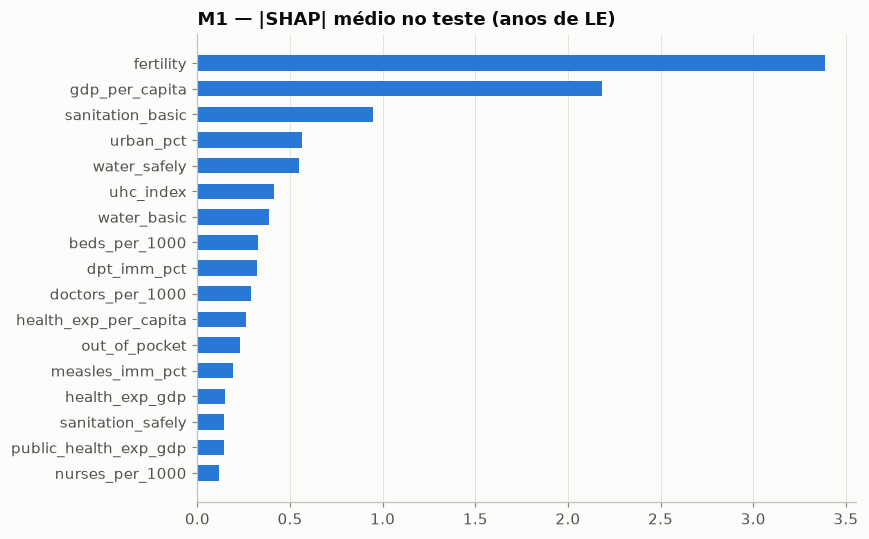

In [6]:
import shap
X = md_.X_test
sv = shap.TreeExplainer(m1).shap_values(X)
imp = pd.Series(np.abs(sv).mean(0), index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp.index, imp.values, color=style.HIGHLIGHT, height=0.6)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_title("M1 — |SHAP| médio no teste (anos de LE)"); plt.tight_layout(); plt.show()

**Leitura:** fertilidade e PIB dominam — os modelos capturam sobretudo o **estágio de
desenvolvimento**. Insumos de saúde (saneamento, vacinas, proxy UHC) entram depois. Como na
EDA, isso é associação preditiva, **não** causal: para efeito causal ver notebook 05.